In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
meta = pd.read_csv('/content/drive/MyDrive/Battery-health-predictor/data/raw/metadata.csv')
meta.head()

Mounted at /content/drive


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [2]:
discharge_meta = meta[meta["type"] == "discharge"].reset_index(drop=True)
discharge_meta["Capacity"] = pd.to_numeric(discharge_meta["Capacity"], errors='coerce')

initial_capacity = discharge_meta.loc[0,"Capacity"]

discharge_meta["battery_health"] = (discharge_meta["Capacity"] / initial_capacity) * 100

In [3]:
import os
data_path = "/content/drive/MyDrive/Battery-health-predictor/data/raw/data"
filename = discharge_meta.loc[0, "filename"]
cycle_data = pd.read_csv(os.path.join(data_path, filename))
cycle_data.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


In [4]:
rows = []

for i, row in discharge_meta.iterrows():
  file = row["filename"]
  df = pd.read_csv(os.path.join(data_path, file))

  rows.append({
        "battery_id": row["battery_id"],

        "voltage_mean": df["Voltage_measured"].mean(),
        "voltage_max": df["Voltage_measured"].max(),
        "voltage_std": df["Voltage_measured"].std(),

        "current_mean": df["Current_measured"].mean(),
        "current_std": df["Current_measured"].std(),

        "temp_max": df["Temperature_measured"].max(),
        "temp_mean": df["Temperature_measured"].mean(),

        "discharge_time": df["Time"].max(),
        "battery_health": row["battery_health"]
    })

final_df = pd.DataFrame(rows)

**Data cleaning**

In [5]:
final_df.isnull().sum()
final_df.info()

final_df = final_df.dropna()

final_df = final_df[final_df["battery_health"] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2794 entries, 0 to 2793
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_id      2794 non-null   object 
 1   voltage_mean    2794 non-null   float64
 2   voltage_max     2794 non-null   float64
 3   voltage_std     2794 non-null   float64
 4   current_mean    2794 non-null   float64
 5   current_std     2794 non-null   float64
 6   temp_max        2794 non-null   float64
 7   temp_mean       2794 non-null   float64
 8   discharge_time  2794 non-null   float64
 9   battery_health  2769 non-null   float64
dtypes: float64(9), object(1)
memory usage: 218.4+ KB


**Exploratory Data Analysis**

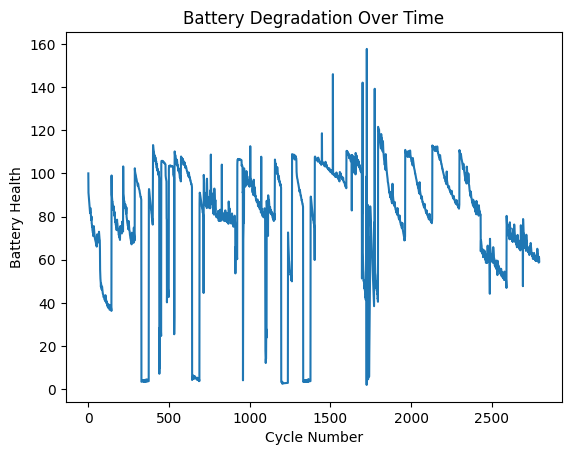

In [6]:
import matplotlib.pyplot as plt

plt.plot(final_df.index, final_df["battery_health"])
plt.xlabel("Cycle Number")
plt.ylabel("Battery Health")
plt.title("Battery Degradation Over Time")
plt.show()

In [7]:
final_df.to_csv('/content/drive/MyDrive/Battery-health-predictor/data/cleaned_battery_data.csv', index=False)

**Exploratory Data Analysis Completed**

Next: 02_feature_engineering.ipynb